**Prática de Suavização de Imagens**

(filtro passa baixa)

Exercícios retirados de:
http://homepages.inf.ed.ac.uk/rbf/HIPR2/mean.htm

http://homepages.inf.ed.ac.uk/rbf/HIPR2/gsmooth.htm

http://homepages.inf.ed.ac.uk/rbf/HIPR2/median.htm

1)	Aplique o filtro de Média a imagem abaixo para diferentes tamanhos de máscaras.
- 3x3; 7x7; 3x3 aplicado três vezes sequenciais.

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

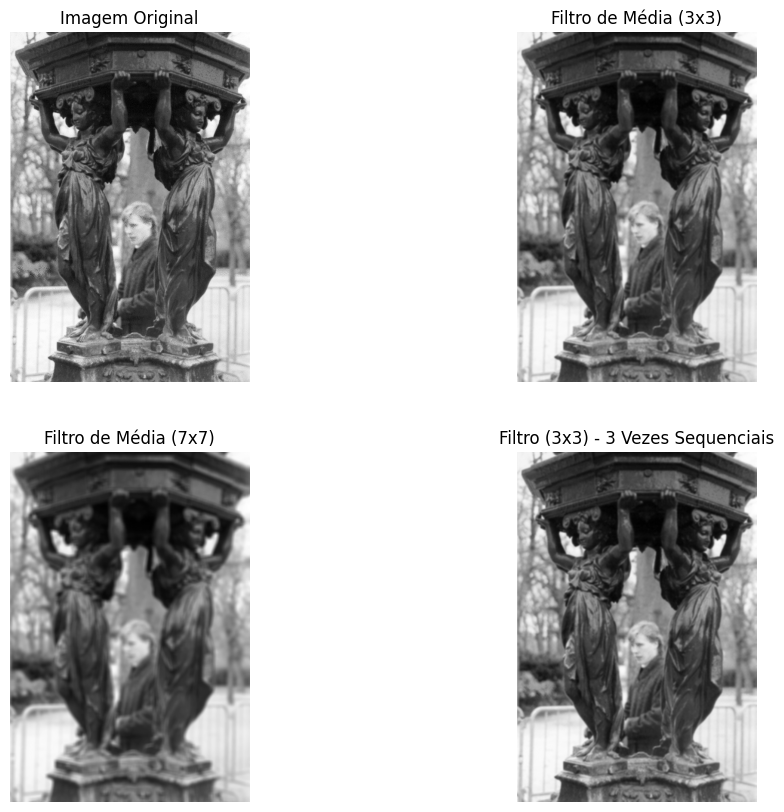

In [3]:
def filtro_media(imagem, k):    
    img_filtrada = np.zeros_like(imagem)
    altura, largura = imagem.shape[:2]

    for y in range(altura):
        for x in range(largura):
            regiao = img[y:y+k, x:x+k]
            
            img_filtrada[y, x] = np.mean(regiao, axis=(0, 1))
            
    return img_filtrada

img = cv2.imread("sta2.png", cv2.IMREAD_GRAYSCALE)


img_3x3 = filtro_media(img, 3)

img_7x7 = filtro_media(img,7)

img_3x3_seq2 = filtro_media(img_3x3, 3)
img_3x3_seq3 = filtro_media(img_3x3_seq2, 3)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
axs[0, 0].imshow(img, cmap='gray')
axs[0, 0].set_title('Imagem Original')
axs[0, 0].axis('off')

axs[1, 0].imshow(img_7x7, cmap='gray')
axs[1, 0].set_title('Filtro de Média (7x7)')
axs[1, 0].axis('off')

axs[0, 1].imshow(img_3x3, cmap='gray')
axs[0, 1].set_title('Filtro de Média (3x3)')
axs[0, 1].axis('off')

axs[1, 1].imshow(img_3x3_seq3, cmap='gray')
axs[1, 1].set_title('Filtro (3x3) - 3 Vezes Sequenciais')
axs[1, 1].axis('off')

plt.show()


2)	Aplique o filtro Gaussiano à imagem abaixo para diferentes valores de desvio padrão (σ) e tamanho de máscara.
- σ = 1.0 (kernel size 5×5).	σ = 2.0 (kernel size 9×9).	σ =  4.0 (kernel size 15×15).

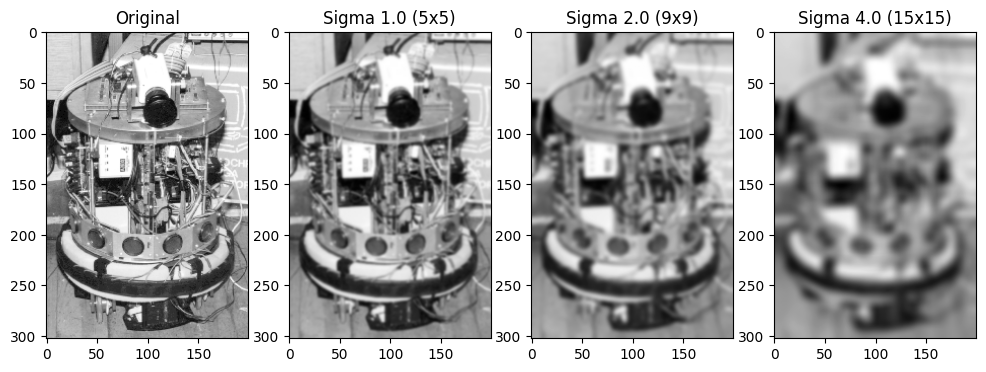

In [6]:
img2 = cv2.imread("ben2.png", cv2.IMREAD_GRAYSCALE)

def convolucao(imagem, kernel):
    altura_img, largura_img = imagem.shape
    tamanho_kernel = kernel.shape[0]
    
    margem = tamanho_kernel // 2
    
    img_padded = np.pad(imagem, margem, mode='reflect')
    
    resultado = np.zeros_like(imagem, dtype=np.float32)

    for i in range(altura_img):
        for j in range(largura_img):
            recorte = img_padded[i:i+tamanho_kernel, j:j+tamanho_kernel]
            
            resultado[i, j] = np.sum(recorte * kernel)

    return np.clip(resultado, 0, 255).astype(np.uint8)

def gerar_kernel_gaussiano(tamanho, sigma):
    kernel = np.zeros((tamanho, tamanho), dtype=np.float32)
    
    centro = tamanho // 2
    soma = 0.0

    for i in range(tamanho):
        for j in range(tamanho):
            x = i - centro
            y = j - centro
            
            exponente = np.exp(-(x**2 + y**2) / (2 * sigma**2))
            valor = (1.0 / (2.0 * np.pi * sigma**2)) * exponente
            
            kernel[i, j] = valor
            soma += valor

    kernel = kernel / soma
    return kernel

def aplicar_gaussiano(imagem, tamanho, sigma):
    kernel = gerar_kernel_gaussiano(tamanho, sigma)
    img_filtrada = convolucao(imagem, kernel)
    
    return img_filtrada


res_sigma1 = aplicar_gaussiano(img2, 5, 1.0) #5x5

res_sigma2 = aplicar_gaussiano(img2, 9, 2.0) #9x9

res_sigma4 = aplicar_gaussiano(img2, 15, 4.0) #15x15

plt.figure(figsize=(12, 5))

plt.subplot(1, 4, 1)
plt.imshow(img2, cmap='gray')
plt.title('Original')

plt.subplot(1, 4, 2)
plt.imshow(res_sigma1, cmap='gray')
plt.title('Sigma 1.0 (5x5)')

plt.subplot(1, 4, 3)
plt.imshow(res_sigma2, cmap='gray')
plt.title('Sigma 2.0 (9x9)')

plt.subplot(1, 4, 4)
plt.imshow(res_sigma4, cmap='gray')
plt.title('Sigma 4.0 (15x15)')

plt.show()

3)	Aplique o filtro de Mediana para a imagem abaixo, que apresenta um ruído *salt and pepper*
-	3×3 filter;	7×7 filter

Calculando Mediana 3x3... (Aguarde: Pc lento do lab....)
Calculando Mediana 7x7... (Aguarde: Pc lento do lab....)


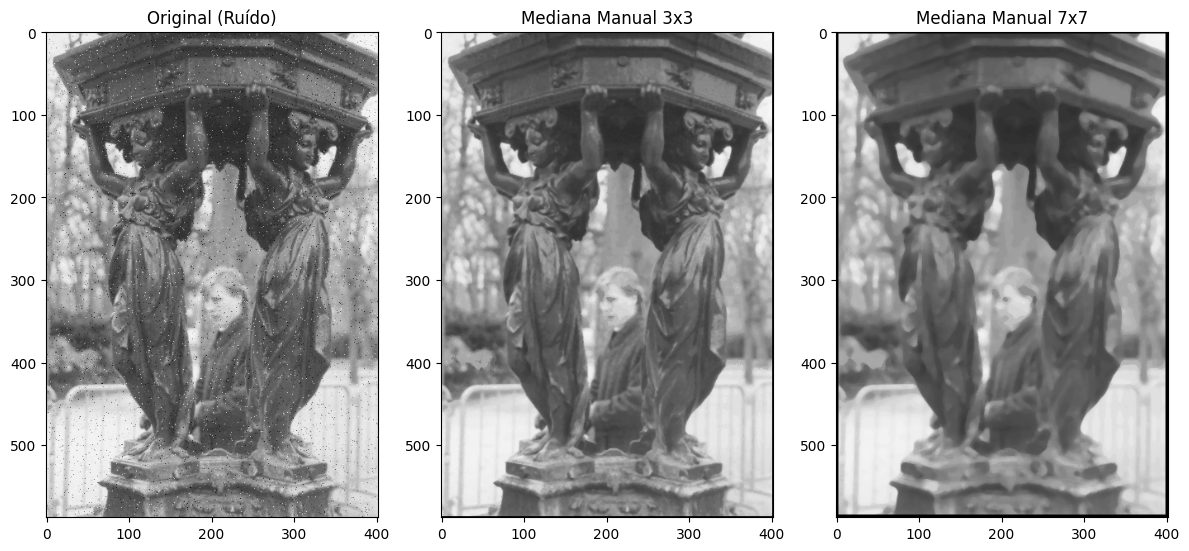

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img3 = cv2.imread("sta2noi2.png", cv2.IMREAD_GRAYSCALE)

def filtro_mediana(imagem, tam_kernel):
    altura, largura = imagem.shape
    borda = tam_kernel // 2
    
    img_saida = np.zeros_like(imagem)
    
    print(f"Calculando Mediana {tam_kernel}x{tam_kernel}...")
    
    for y in range(borda, altura - borda):
        for x in range(borda, largura - borda):
            
            janela = imagem[y - borda : y + borda + 1, x - borda : x + borda + 1]
            valor_mediana = np.median(janela)
            img_saida[y, x] = int(valor_mediana)
            
    return img_saida

res_manual_3 = filtro_mediana(img3, 3)
res_manual_7 = filtro_mediana(img3, 7)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(img3, cmap='gray', vmin=0, vmax=255)
plt.title('Original (Ruído)')

plt.subplot(1, 3, 2)
plt.imshow(res_manual_3, cmap='gray', vmin=0, vmax=255)
plt.title('Mediana Manual 3x3')

plt.subplot(1, 3, 3)
plt.imshow(res_manual_7, cmap='gray', vmin=0, vmax=255)
plt.title('Mediana Manual 7x7')

plt.tight_layout()
plt.show()

4)	Aplique o filtro de Mediana para a imagem abaixo, que apresenta um ruído salt and pepper
- 3×3 filter;	7×7 filter

Aguarde (pc lento do lab) - Processando Mediana 3x3 na imagem 4...
Aguarde (pc lento do lab) - Processando Mediana 7x7 na imagem 4...


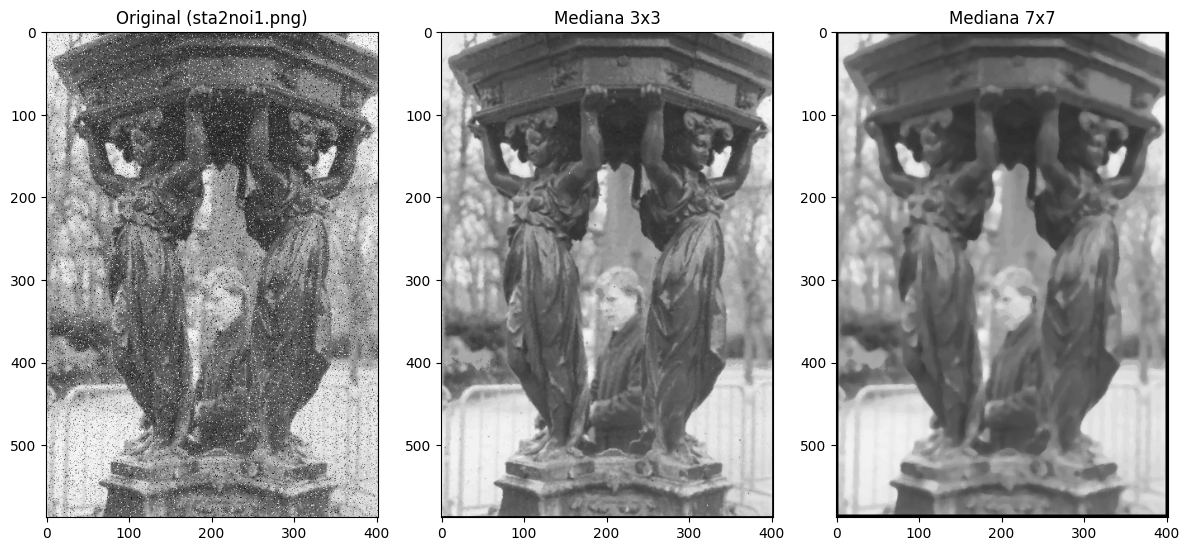

In [ ]:
img4 = cv2.imread("sta2noi1.png", cv2.IMREAD_GRAYSCALE)


def filtro_mediana(imagem, tam_kernel):
    altura, largura = imagem.shape
    borda = tam_kernel // 2
    
    img_saida = np.zeros_like(imagem)
    
    print(f"Processando Mediana {tam_kernel}x{tam_kernel} na imagem 4...")
    
    for y in range(borda, altura - borda):
        for x in range(borda, largura - borda):
            janela = imagem[y - borda : y + borda + 1, x - borda : x + borda + 1]
            
            mediana = np.median(janela)
            img_saida[y, x] = int(mediana)
            
    return img_saida


res_mediana_3 = filtro_mediana(img4, 3)
res_mediana_7 = filtro_mediana(img4, 7)

plt.figure(figsize=(12, 6))


plt.subplot(1, 3, 1)
plt.imshow(img4, cmap='gray', vmin=0, vmax=255)
plt.title('Original (sta2noi1.png)')

plt.subplot(1, 3, 2)
plt.imshow(res_mediana_3, cmap='gray', vmin=0, vmax=255)
plt.title('Mediana 3x3')

plt.subplot(1, 3, 3)
plt.imshow(res_mediana_7, cmap='gray', vmin=0, vmax=255)
plt.title('Mediana 7x7')

plt.tight_layout()
plt.show()